#### Implementation
### Bài tập 1

In [1]:
# dataset
#!gdown 1GmYeNtWTvah2VHL1EPSTMdfbMqfjFITc
#!unzip advertising.zip

import numpy as np
import matplotlib.pyplot as plt
import random

def get_column(data: list[list], index):

    #***your code here***
    result = list(map(lambda x: x[index], data))

    return result

def prepare_data(file_name_dataset):
  data = np.genfromtxt(file_name_dataset, delimiter=',', skip_header=1).tolist()
  N = len(data)

  # get tv (index=0)
  tv_data = get_column(data, 0)

  # get radio (index=1)
  radio_data = get_column(data, 1)

  # get newspaper (index=2)
  newspaper_data = get_column(data, 2)

  # get sales (index=3)
  sales_data = get_column(data, 3)

  # building X input  and y output for training
  X = [tv_data, radio_data, newspaper_data]
  y = sales_data

  return X, y

In [2]:
X, y = prepare_data('../Data/advertising.csv')
lst = [sum(X[0][:5]), sum(X[1][:5]), sum(X[2][:5]), sum(y[:5])]
print(lst)

[624.1, 175.1, 300.5, 78.9]


### Bài tập 2

In [3]:
def initialize_params():
    # w1 = random.gauss(mu=0.0, sigma=0.01)
    # w2 = random.gauss(mu=0.0, sigma=0.01)
    # w3 = random.gauss(mu=0.0, sigma=0.01)
    # b  = 0

    w1, w2, w3, b = (0.016992259082509283, 0.0070783670518262355, -0.002307860847821344, 0)
    return w1, w2, w3, b

print(initialize_params())

(0.016992259082509283, 0.0070783670518262355, -0.002307860847821344, 0)


In [4]:
# compute output and loss
def predict(x1, x2, x3, w1, w2, w3, b):

    #***your code here***
    result = b + x1*w1 + x2*w2 + x3*w3

    return result

def compute_loss(y_hat, y):

    #***your code here***
    result = (y_hat - y)**2

    return result


# compute gradient
def compute_gradient_wi(xi, y, y_hat):

    #***your code here***
    dl_dwi = (y_hat - y)*xi

    return dl_dwi

def compute_gradient_b(y, y_hat):

    #***your code here***
    dl_db = (y_hat - y)

    return dl_db

# update weights
def update_weight_wi(wi, dl_dwi, lr):

    #***your code here***
    wi = wi - lr*dl_dwi

    return wi

def update_weight_b(b, dl_db, lr):

    #***your code here***
    b = b - lr*dl_db

    return b

In [5]:
y_p = predict(x1 = 1, x2 =1, x3=1, w1=0, w2=0.5, w3=0, b=0.5)
print(y_p)

1.0


In [6]:
l = compute_loss(y_hat=1, y=0.5)
print(l)

0.25


In [7]:
# compute gradient
g_wi = compute_gradient_wi(xi=1.0, y=1.0, y_hat=0.5)
print(g_wi)

-0.5


In [8]:
g_b =  compute_gradient_b(y=2.0, y_hat=0.5)
print(g_b)

-1.5


In [9]:
after_wi = update_weight_wi(wi=1.0, dl_dwi=-0.5, lr = 1e-5)
print(after_wi)

1.000005


In [10]:
after_b = update_weight_b(b=0.5, dl_db=-1.0, lr = 1e-5)
print(after_b)


0.50001


In [11]:
def implement_linear_regression(X_data, y_data, epoch_max=50, lr=1e-5):
  losses = []

  w1, w2, w3, b = initialize_params()

  N = len(y_data)
  for epoch in range(epoch_max):
      for i in range(N):
          # get a sample
          x1 = X_data[0][i]
          x2 = X_data[1][i]
          x3 = X_data[2][i]

          y  = y_data[i]

          # print(y)
          # compute output
          y_hat = predict(x1, x2, x3, w1, w2, w3, b)

          # compute loss
          loss = compute_loss(y, y_hat)

          # compute gradient w1, w2, w3, b
          dl_dw1 = compute_gradient_wi(x1, y, y_hat)
          dl_dw2 = compute_gradient_wi(x2, y, y_hat)
          dl_dw3 = compute_gradient_wi(x3, y, y_hat)
          dl_db  = compute_gradient_b(y, y_hat)

          # update parameters
          w1 = update_weight_wi(w1, dl_dw1, lr)
          w2 = update_weight_wi(w2, dl_dw2, lr)
          w3 = update_weight_wi(w3, dl_dw3, lr)
          b  = update_weight_b(b, dl_db, lr)

          # logging
          losses.append(loss)
  return (w1, w2, w3, b, losses)

[326.9667843262905, 46.03755232863168, 85.7404409110882, 24.12220472346936, 12.684824117105283, 12.564505263193471, 34.67331940022175, 6.911464802753735, 15.927663906090466, 3.7184854328921713, 41.35645675408837, 2.4697604589341364, 18.632161675753462, 27.183239167020385, 1.8036659829765078, 7.520829197972803, 1.9427397657362593, 19.504569944150628, 21.712040783831696, 1.4039123401419202, 8.501453102336491, 3.026246608972732, 6.563646717793318, 5.59061226739292, 14.32496913536011, 26.191548461957996, 16.073472009485897, 3.8351572207229925, 4.831230023756761, 12.006145422437799, 9.258190735833297, 6.533118421766791, 28.88532126719924, 8.82742288984051, 27.33237914182363, 11.557385612772322, 55.407394464996514, 27.195292944365015, 16.320658592571824, 1.1870358795656013, 7.015094571351298, 0.09098056467987617, 14.401208454478017, 5.528000983998824, 15.676990991711541, 0.7981844627008662, 3.550232057443143, 4.8669450296600205, 3.419547141395398, 5.763998304802906, 1.68021307163357, 5.59763

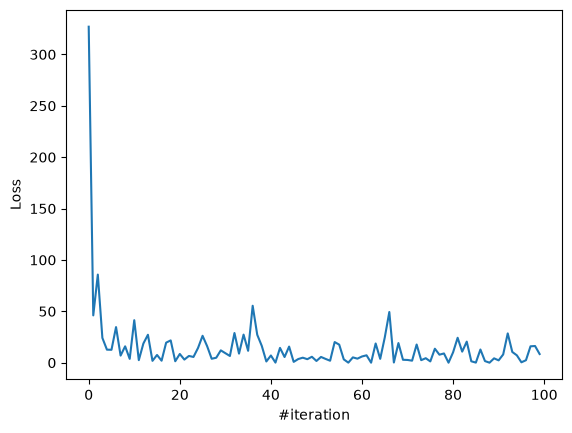

In [12]:
X, y = prepare_data('../Data/advertising.csv')
(w1, w2, w3, b, losses) = implement_linear_regression(X,y)
print(losses[0:100])
plt.plot(losses[0:100])
plt.xlabel("#iteration")
plt.ylabel("Loss")
plt.show()

In [14]:
X,y = prepare_data('../Data/advertising.csv')
(w1, w2, w3, b, losses) = implement_linear_regression(X,y)
print(w1, w2, w3)

0.06822256448061412 0.16106167996983922 0.020299787625454525


#### Inference

In [15]:
# given new data
tv = 19.2
radio = 35.9
newspaper = 51.3

X,y = prepare_data('../Data/advertising.csv')
(w1, w2, w3, b, losses) = implement_linear_regression(X,y)
sales = predict(tv, radio, newspaper, w1, w2, w3, b)
print(f'predicted sales is {sales}')

predicted sales is 8.205853574595645


### Data normalization

In [16]:
# ---------------------------
# 1. Min-Max Scaling
# ---------------------------
def min_max_scaling(X):
    mins = []
    maxs = []
    X_scaled = []

    # Tìm min và max cho từng feature
    for feature in X:
        min_val = min(feature)
        max_val = max(feature)
        mins.append(min_val)
        maxs.append(max_val)

        # Scale từng phần tử
        scaled_feature = []
        for x in feature:
            scaled_x = (x - min_val) / (max_val - min_val)
            scaled_feature.append(scaled_x)

        X_scaled.append(scaled_feature)

    return X_scaled, mins, maxs


# ---------------------------
# 2. Inverse Min-Max
# ---------------------------
def inverse_min_max_scaling(X_scaled, mins, maxs):
    X_recovered = []

    for i in range(len(X_scaled)):
        feature = X_scaled[i]
        min_val = mins[i]
        max_val = maxs[i]

        recovered_feature = []
        for x in feature:
            original_x = x * (max_val - min_val) + min_val
            recovered_feature.append(original_x)

        X_recovered.append(recovered_feature)

    return X_recovered

In [17]:
# ---------------------------
# 3. Z-Score Scaling
# ---------------------------
def z_score_scaling(X):
    means = []
    stds = []
    X_scaled = []

    for feature in X:
        mean_val = sum(feature) / len(feature)
        means.append(mean_val)

        std_val = (sum((x - mean_val) ** 2 for x in feature) / (len(feature) - 1)) ** 0.5
        stds.append(std_val)

        scaled_feature = []
        for x in feature:
            scaled_x = (x - mean_val) / std_val
            scaled_feature.append(scaled_x)

        X_scaled.append(scaled_feature)

    return X_scaled, means, stds


# ---------------------------
# 4. Inverse Z-Score
# ---------------------------
def inverse_z_score_scaling(X_scaled, means, stds):
    X_recovered = []

    for i in range(len(X_scaled)):
        feature = X_scaled[i]
        mean_val = means[i]
        std_val = stds[i]

        recovered_feature = []
        for x in feature:
            original_x = x * std_val + mean_val
            recovered_feature.append(original_x)

        X_recovered.append(recovered_feature)

    return X_recovered

In [18]:
# ---------------------------
# Ví dụ chạy thử
# ---------------------------
data1 = [1, 2, 3]
data2 = [4, 5, 6]
data3 = [7, 8, 9]
X = [data1, data2, data3]

# Min-Max
X_minmax, mins, maxs = min_max_scaling(X)
print("Min-Max Scaled:", X_minmax)
print("Recovered Min-Max:", inverse_min_max_scaling(X_minmax, mins, maxs))

# Z-Score
X_zscore, means, stds = z_score_scaling(X)
print("\nZ-Score Scaled:", X_zscore)
print("Recovered Z-Score:", inverse_z_score_scaling(X_zscore, means, stds))

Min-Max Scaled: [[0.0, 0.5, 1.0], [0.0, 0.5, 1.0], [0.0, 0.5, 1.0]]
Recovered Min-Max: [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]

Z-Score Scaled: [[-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0]]
Recovered Z-Score: [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]
